# Measurement Error & Decision Risk
### A Monte Carlo Simulation Study Inspired by GRR Systems

Author: eng. Simeon Petkov  
Course: Math for Developers – Final Exam Project

## Abstract

In industrial testing environments, acceptance decisions are typically based on measured values compared against specification limits. However, every measurement system introduces variation, which may lead to incorrect decisions.

This project models both process variation and measurement system variation using probabilistic methods. A Monte Carlo simulation framework is developed to estimate the probability of false pass and false fail decisions under varying measurement conditions.

The objective is to quantify decision risk and analyze how measurement system quality influences product acceptance reliability.

## 1. Problem Definition

Consider a product characteristic measured during an End-of-Line (EOL) test.

A decision is made according to a lower specification limit (LSL).  
If the measured value is above the limit, the product is accepted; otherwise, it is rejected.

However, the measured value is not equal to the true value due to measurement system variation.

The central question of this study is:

> What is the probability of making an incorrect pass/fail decision due solely to measurement system error?

We aim to model this problem mathematically and estimate the associated decision risk using simulation techniques.

## 2. Mathematical Model

### 2.1 True Process Distribution

The true product characteristic is assumed to follow a normal distribution:

$$
X_{\text{true}} \sim \mathcal{N}(\mu_p, \sigma_p)
$$

where:

- \( \mu_p \) is the process mean  
- \( \sigma_p \) is the process standard deviation  

This represents the natural variation of the manufacturing process.

### 2.2 Measurement Error Model

The measurement system introduces random error:

$$
\varepsilon \sim \mathcal{N}(0, \sigma_m)
$$

The measured value is therefore:

$$
X_{\text{measured}} = X_{\text{true}} + \varepsilon
$$

where:

- \( \sigma_m \) is the measurement system standard deviation  
- \( \varepsilon \) represents random measurement noise  

This model assumes that the measurement error is unbiased and independent of the true value.

### 2.3 Decision Rule

Let \( LSL \) denote the lower specification limit.

The acceptance criterion is defined as:

$$
\text{Accept if } X_{\text{measured}} \geq LSL
$$

and

$$
\text{Reject if } X_{\text{measured}} < LSL
$$

The decision is therefore based on the measured value rather than the true value.

### 2.4 Decision Error Types

Because the decision is based on the measured value rather than the true value, incorrect decisions may occur.

Two types of decision errors are possible:

#### False Fail (Type I Decision Error)

A conforming product is rejected:

$$
X_{\text{true}} \geq LSL 
\quad \text{and} \quad 
X_{\text{measured}} < LSL
$$

#### False Pass (Type II Decision Error)

A nonconforming product is accepted:

$$
X_{\text{true}} < LSL 
\quad \text{and} \quad 
X_{\text{measured}} \geq LSL
$$

These probabilities quantify the risk introduced solely by measurement system variation.

### 2.5 Monte Carlo Estimation

Let \( N \) be the number of simulated products.

The probability of false fail is estimated as:

$$
\hat{P}_{FF} = \frac{n_{FF}}{N}
$$

where \( n_{FF} \) is the number of simulated cases for which:

$$
X_{\text{true}} \geq LSL \quad \text{and} \quad X_{\text{measured}} < LSL
$$

The probability of false pass is estimated as:

$$
\hat{P}_{FP} = \frac{n_{FP}}{N}
$$

where \( n_{FP} \) is the number of simulated cases for which:

$$
X_{\text{true}} < LSL \quad \text{and} \quad X_{\text{measured}} \geq LSL
$$

As \( N \) increases, these estimates converge to the true probabilities.

## 3. First Simulation Implementation (Monte Carlo)

This section implements the Monte Carlo estimation of false pass and false fail probabilities based on the mathematical model defined above.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
# --- Simulation Parameters ---

MU_P = 10.0        # Process mean
SIGMA_P = 1.0      # Process standard deviation
SIGMA_M = 0.5      # Measurement system standard deviation
LSL = 8.0          # Lower specification limit

DEFAULT_N = 200_000
DEFAULT_SEED = 123

In [23]:
import numpy as np


def simulate_decision_risk(
    mu_p: float,
    sigma_p: float,
    sigma_m: float,
    lsl: float,
    n: int = DEFAULT_N,
    seed: int = DEFAULT_SEED
) -> dict:
    """
    Estimate false fail and false pass probabilities using Monte Carlo simulation.

    Parameters
    ----------
    mu_p : float
        Mean of the true process distribution.
    sigma_p : float
        Standard deviation of the true process distribution.
    sigma_m : float
        Standard deviation of the measurement error distribution.
    lsl : float
        Lower specification limit.
    n : int, optional
        Number of simulated samples.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    dict
        Dictionary containing simulation inputs and estimated decision risks.
    """
    rng = np.random.default_rng(seed)

    x_true = rng.normal(loc=mu_p, scale=sigma_p, size=n)
    measurement_error = rng.normal(loc=0.0, scale=sigma_m, size=n)
    x_measured = x_true + measurement_error

    true_conforming = x_true >= lsl
    decided_accept = x_measured >= lsl

    false_fail = true_conforming & (~decided_accept)
    false_pass = (~true_conforming) & decided_accept

    return {
        "N": n,
        "mu_p": mu_p,
        "sigma_p": sigma_p,
        "sigma_m": sigma_m,
        "LSL": lsl,
        "P_false_fail": float(false_fail.mean()),
        "P_false_pass": float(false_pass.mean()),
    }

In [24]:
result = simulate_decision_risk(
    mu_p=MU_P,
    sigma_p=SIGMA_P,
    sigma_m=SIGMA_M,
    lsl=LSL,
    n=DEFAULT_N,
    seed=1
)

result

{'N': 200000,
 'mu_p': 10.0,
 'sigma_p': 1.0,
 'sigma_m': 0.5,
 'LSL': 8.0,
 'P_false_fail': 0.020275,
 'P_false_pass': 0.00624}

### 3.1 Initial Test Case

The first simulation run demonstrates that even when the process mean is above the specification limit, measurement noise can still produce a nonzero probability of false fail and false pass decisions.

### 3.2 Interpretation of the First Simulation

The simulation results indicate that measurement system variation can introduce a measurable level of decision risk.

In this example:

- The estimated probability of **false fail** is approximately **2%**.
- The estimated probability of **false pass** is approximately **0.6%**.

This means that even when the process is centered above the specification limit, measurement noise can still cause correct products to be rejected and nonconforming products to be accepted.

These results demonstrate the importance of controlling measurement system variation when making pass/fail decisions in industrial testing.

## 4. Validation Checks

This section verifies that the Monte Carlo simulation behaves consistently and produces logically valid results under controlled conditions.

In [28]:
# Validation Check 1: Output structure and probability range

test_result = simulate_decision_risk(
    mu_p=MU_P,
    sigma_p=SIGMA_P,
    sigma_m=SIGMA_M,
    lsl=LSL,
    n=100_000,
    seed=123
)

print(test_result)

assert 0.0 <= test_result["P_false_fail"] <= 1.0
assert 0.0 <= test_result["P_false_pass"] <= 1.0

print("Validation Check 1 passed: probabilities are within [0, 1].")

{'N': 100000, 'mu_p': 10.0, 'sigma_p': 1.0, 'sigma_m': 0.5, 'LSL': 8.0, 'P_false_fail': 0.02056, 'P_false_pass': 0.00633}
Validation Check 1 passed: probabilities are within [0, 1].


In [29]:
# Validation Check 2: No measurement error should produce no decision risk

zero_error_result = simulate_decision_risk(
    mu_p=MU_P,
    sigma_p=SIGMA_P,
    sigma_m=0.0,
    lsl=LSL,
    n=100_000,
    seed=123
)

print(zero_error_result)

assert zero_error_result["P_false_fail"] == 0.0
assert zero_error_result["P_false_pass"] == 0.0

print("Validation Check 2 passed: zero measurement error gives zero decision risk.")

{'N': 100000, 'mu_p': 10.0, 'sigma_p': 1.0, 'sigma_m': 0.0, 'LSL': 8.0, 'P_false_fail': 0.0, 'P_false_pass': 0.0}
Validation Check 2 passed: zero measurement error gives zero decision risk.


In [30]:
# Validation Check 3: Same seed should reproduce the same result

result_a = simulate_decision_risk(
    mu_p=MU_P,
    sigma_p=SIGMA_P,
    sigma_m=SIGMA_M,
    lsl=LSL,
    n=100_000,
    seed=999
)

result_b = simulate_decision_risk(
    mu_p=MU_P,
    sigma_p=SIGMA_P,
    sigma_m=SIGMA_M,
    lsl=LSL,
    n=100_000,
    seed=999
)

assert result_a["P_false_fail"] == result_b["P_false_fail"]
assert result_a["P_false_pass"] == result_b["P_false_pass"]

print("Validation Check 3 passed: identical seed gives identical simulation output.")

Validation Check 3 passed: identical seed gives identical simulation output.


In [31]:
# Validation Check 4: Higher measurement error should generally increase decision risk

low_noise = simulate_decision_risk(
    mu_p=MU_P,
    sigma_p=SIGMA_P,
    sigma_m=0.2,
    lsl=LSL,
    n=100_000,
    seed=123
)

high_noise = simulate_decision_risk(
    mu_p=10.0,
    sigma_p=1.0,
    sigma_m=0.8,
    lsl=8.0,
    n=100_000,
    seed=123
)

print("Low noise:", low_noise)
print("High noise:", high_noise)

assert high_noise["P_false_fail"] >= low_noise["P_false_fail"]
assert high_noise["P_false_pass"] >= low_noise["P_false_pass"]

print("Validation Check 4 passed: larger measurement error increases decision risk.")

Low noise: {'N': 100000, 'mu_p': 10.0, 'sigma_p': 1.0, 'sigma_m': 0.2, 'LSL': 8.0, 'P_false_fail': 0.00578, 'P_false_pass': 0.00355}
High noise: {'N': 100000, 'mu_p': 10.0, 'sigma_p': 1.0, 'sigma_m': 0.8, 'LSL': 8.0, 'P_false_fail': 0.04414, 'P_false_pass': 0.00788}
Validation Check 4 passed: larger measurement error increases decision risk.


### 4.1 Validation Summary

The validation checks confirm that the simulation behaves as expected under controlled conditions.

The results show that:

- estimated probabilities remain within valid bounds;
- zero measurement error produces zero false decisions;
- repeated runs with the same random seed are reproducible;
- larger measurement variation leads to higher decision risk.

These checks support the correctness of the simulation model before proceeding to broader experiments and visualization.

## 5. Experiment: Decision Risk vs Measurement Error

This experiment evaluates how the probability of false fail and false pass decisions changes as the measurement system standard deviation increases.

The process parameters are kept constant, while the measurement error parameter \( \sigma_m \) is varied across a predefined range.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
sigma_m_values = np.arange(0.0, 1.1, 0.1)

experiment_results = []

for sigma_m in sigma_m_values:
    simulation_result = simulate_decision_risk(
        mu_p=MU_P,
        sigma_p=SIGMA_P,
        sigma_m=float(sigma_m),
        lsl=LSL,
        n=DEFAULT_N,
        seed=DEFAULT_SEED
    )
    experiment_results.append(simulation_result)

df_results = pd.DataFrame(experiment_results)
df_results

,N,mu_p,sigma_p,sigma_m,LSL,P_false_fail,P_false_pass
0,200000,10.0,1.0,0.0,8.0,0.000000,0.000000
1,200000,10.0,1.0,0.1,8.0,0.002430,0.001810
2,200000,10.0,1.0,0.2,8.0,0.005745,0.003185
3,200000,10.0,1.0,0.3,8.0,0.009870,0.004240
4,200000,10.0,1.0,0.4,8.0,0.014645,0.005240
5,200000,10.0,1.0,0.5,8.0,0.020500,0.006030
6,200000,10.0,1.0,0.6,8.0,0.027175,0.006670
7,200000,10.0,1.0,0.7,8.0,0.035300,0.007205
8,200000,10.0,1.0,0.8,8.0,0.043840,0.007565
9,200000,10.0,1.0,0.9,8.0,0.053630,0.007945


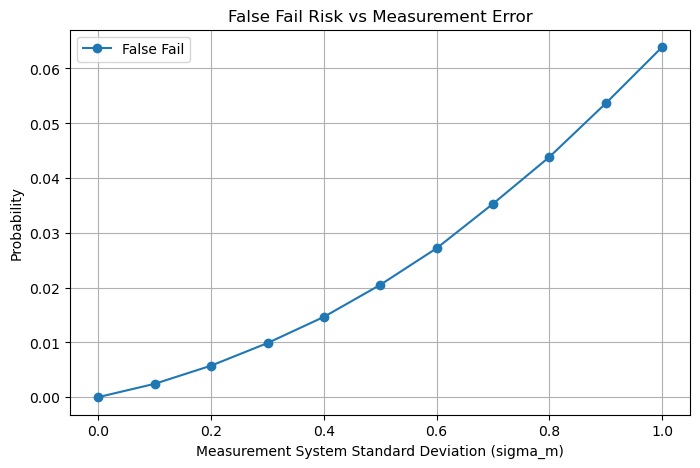

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["sigma_m"], df_results["P_false_fail"], marker="o", label="False Fail")
plt.xlabel("Measurement System Standard Deviation (sigma_m)")
plt.ylabel("Probability")
plt.title("False Fail Risk vs Measurement Error")
plt.grid(True)
plt.legend()
plt.show()

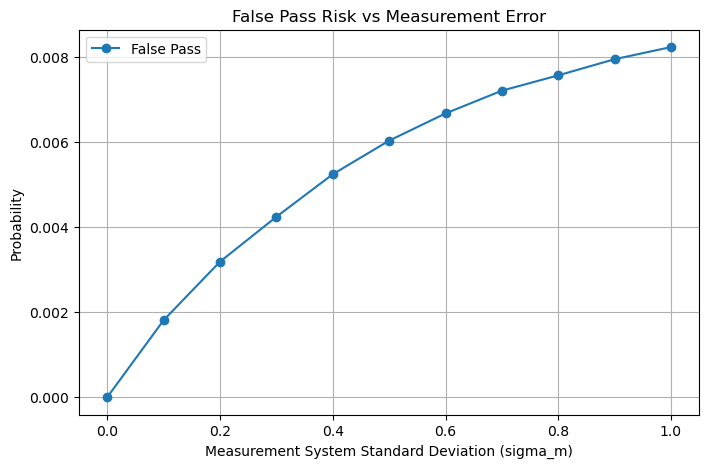

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["sigma_m"], df_results["P_false_pass"], marker="o", label="False Pass")
plt.xlabel("Measurement System Standard Deviation (sigma_m)")
plt.ylabel("Probability")
plt.title("False Pass Risk vs Measurement Error")
plt.grid(True)
plt.legend()
plt.show()

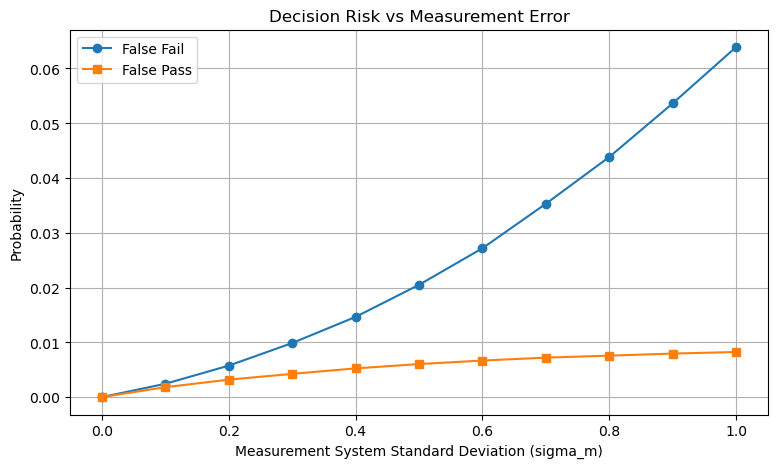

In [38]:
plt.figure(figsize=(9, 5))
plt.plot(df_results["sigma_m"], df_results["P_false_fail"], marker="o", label="False Fail")
plt.plot(df_results["sigma_m"], df_results["P_false_pass"], marker="s", label="False Pass")
plt.xlabel("Measurement System Standard Deviation (sigma_m)")
plt.ylabel("Probability")
plt.title("Decision Risk vs Measurement Error")
plt.grid(True)
plt.legend()
plt.show()

### 5.1 Interpretation of Experimental Results

The results show that decision risk increases as measurement system variation increases.

Both false fail and false pass probabilities rise with increasing \( \sigma_m \), confirming that measurement uncertainty directly affects the reliability of pass/fail decisions.

This behavior is consistent with the theoretical expectation that noisier measurement systems lead to greater overlap around the specification boundary and therefore more classification errors.

## 6. Visualization of Measurement Error Effects

To better understand the effect of measurement uncertainty on pass/fail decisions, we visualize the relationship between:

- the true product characteristic
- the measured value
- the specification limit

The following visualizations illustrate how measurement noise can shift measurements across the decision boundary.

In [41]:
# Process parameters
mu_p = 10.0        # process mean
sigma_p = 1.0      # process standard deviation

# Measurement system
sigma_m = 0.5      # measurement noise

# Specification limit
LSL = 8.0

In [42]:
np.random.seed(42)

N_vis = 10_000

x_true_vis = np.random.normal(MU_P, SIGMA_P, N_vis)
measurement_noise = np.random.normal(0, SIGMA_M, N_vis)
x_meas_vis = x_true_vis + measurement_noise

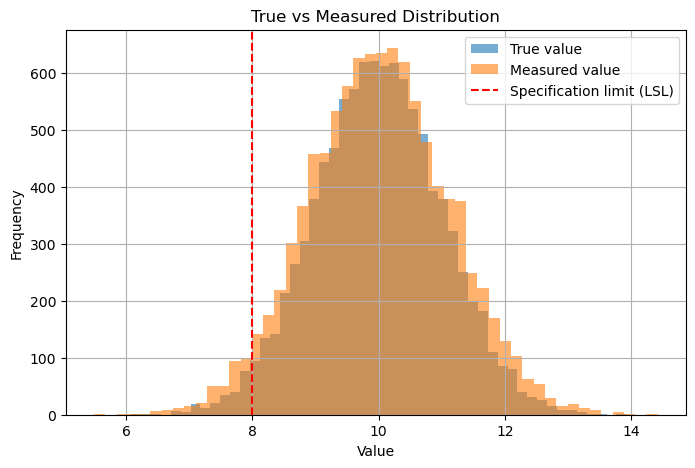

In [43]:
plt.figure(figsize=(8,5))

plt.hist(x_true_vis, bins=50, alpha=0.6, label="True value")
plt.hist(x_meas_vis, bins=50, alpha=0.6, label="Measured value")

plt.axvline(LSL, color="red", linestyle="--", label="Specification limit (LSL)")

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("True vs Measured Distribution")
plt.legend()
plt.grid(True)

plt.show()

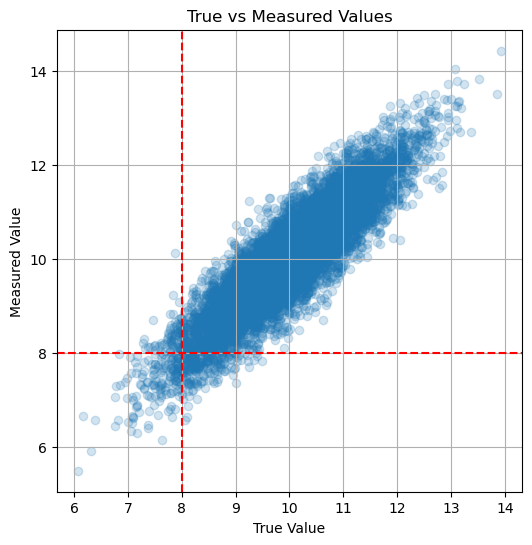

In [44]:
plt.figure(figsize=(6,6))

plt.scatter(x_true_vis, x_meas_vis, alpha=0.2)

plt.axvline(LSL, color="red", linestyle="--")
plt.axhline(LSL, color="red", linestyle="--")

plt.xlabel("True Value")
plt.ylabel("Measured Value")

plt.title("True vs Measured Values")

plt.grid(True)
plt.show()

The square created by the LSL lines visually separates:

True Fail / Measured Fail

True Pass / Measured Pass

False Fail

False Pass

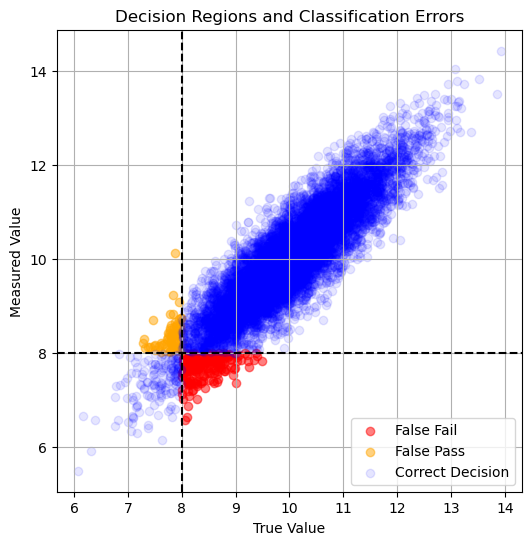

In [46]:
true_pass = x_true_vis >= LSL
measured_pass = x_meas_vis >= LSL

false_fail = true_pass & (~measured_pass)
false_pass = (~true_pass) & measured_pass

plt.figure(figsize=(6,6))

plt.scatter(x_true_vis[false_fail], x_meas_vis[false_fail], 
            color="red", label="False Fail", alpha=0.5)

plt.scatter(x_true_vis[false_pass], x_meas_vis[false_pass], 
            color="orange", label="False Pass", alpha=0.5)

plt.scatter(x_true_vis[~(false_fail | false_pass)], 
            x_meas_vis[~(false_fail | false_pass)], 
            color="blue", alpha=0.1, label="Correct Decision")

plt.axvline(LSL, color="black", linestyle="--")
plt.axhline(LSL, color="black", linestyle="--")

plt.xlabel("True Value")
plt.ylabel("Measured Value")

plt.title("Decision Regions and Classification Errors")

plt.legend()
plt.grid(True)

plt.show()

blue = correct decisions

red = false fail

orange = false pass

### 6.1 Interpretation of the Visualization

The scatter plot illustrates how measurement noise affects pass/fail decisions.

Points near the specification limit are most vulnerable to classification errors. Even when the true value is above the limit, measurement noise may shift the measured value below the limit, resulting in a **false fail**.

Similarly, parts that are truly below the specification limit may be measured above the limit, producing a **false pass**.

These errors occur primarily in the region surrounding the specification boundary and increase as measurement uncertainty increases.

## 7. Results

The Monte Carlo simulation provides quantitative estimates of decision risk caused by measurement uncertainty.

Two types of classification errors are considered:

- **False Fail**: a conforming product is incorrectly rejected.
- **False Pass**: a nonconforming product is incorrectly accepted.

The experiment analyzed how these risks change as the measurement system standard deviation \( \sigma_m \) increases.

In [50]:
summary_results = df_results.copy()

summary_results["False Fail (%)"] = summary_results["P_false_fail"] * 100
summary_results["False Pass (%)"] = summary_results["P_false_pass"] * 100

summary_results[["sigma_m", "False Fail (%)", "False Pass (%)"]]

,sigma_m,False Fail (%),False Pass (%)
0,0.0,0.0000,0.0000
1,0.1,0.2430,0.1810
2,0.2,0.5745,0.3185
3,0.3,0.9870,0.4240
4,0.4,1.4645,0.5240
5,0.5,2.0500,0.6030
6,0.6,2.7175,0.6670
7,0.7,3.5300,0.7205
8,0.8,4.3840,0.7565
9,0.9,5.3630,0.7945


### 7.1 Key Observations

The simulation results show several important trends:

1. When measurement error is very small, decision errors are rare because the measured value closely reflects the true product characteristic.

2. As the measurement system variation increases, both **false fail** and **false pass** probabilities increase.

3. Errors occur primarily near the **specification boundary**, where measurement noise can shift values across the decision threshold.

4. The experiment confirms that measurement system capability plays a critical role in maintaining reliable pass/fail decisions in manufacturing environments.

### 7.2 Interpretation of Visualization

The visualizations presented earlier illustrate the mechanism behind decision risk.

The histogram comparison between true values and measured values shows how measurement noise increases the spread of observed measurements.

The scatter plot of true versus measured values highlights the classification regions defined by the specification limit. Points located near this boundary are most susceptible to misclassification.

The colored decision-region plot clearly demonstrates where **false fail** and **false pass** errors occur, emphasizing that measurement uncertainty can significantly impact quality control decisions.

These results demonstrate that even a relatively small amount of measurement system noise can introduce non-negligible decision risk.

In the following section, we summarize the main findings of the study and discuss the implications for measurement system design and quality control processes.

## 8. Code Quality and Refactoring

To improve readability and maintainability, the notebook was refactored by introducing a centralized parameter section and clearer function structure.

This reduces duplication, improves consistency across experiments, and makes the simulation easier to modify and extend.

## 9. Discussion

The simulation results demonstrate how measurement system variation affects the reliability of pass/fail decisions.

As measurement uncertainty increases, the probability of incorrect decisions also increases. This effect is most pronounced near the specification limit, where small measurement fluctuations can shift observed values across the decision boundary.

The Monte Carlo approach provides a practical way to estimate these decision risks under realistic assumptions about process variation and measurement noise.

The analysis highlights the importance of maintaining a sufficiently capable measurement system to ensure that quality control decisions remain reliable.

### 9.1 Limitations of the Model

Although the simulation provides useful insight into decision risk, several simplifying assumptions were made:

1. **Normal distributions**  
   The model assumes that both process variation and measurement error follow normal distributions. In real manufacturing systems, deviations from normality may occur.

2. **Independent measurement error**  
   The measurement noise was assumed to be independent of the true value. In practice, measurement systems may introduce systematic bias or nonlinear effects.

3. **Single specification limit**  
   The analysis considered only a lower specification limit (LSL). Many real applications involve both lower and upper limits.

4. **Constant process parameters**  
   The process mean and standard deviation were treated as constant. In real systems, process drift may occur over time.

Despite these limitations, the model captures the essential relationship between measurement uncertainty and decision reliability.

### 9.2 Practical Implications

The findings of this study have practical relevance for quality control and measurement system analysis.

If the measurement system variation becomes too large relative to the tolerance limits, the probability of false decisions increases significantly. This can lead to unnecessary rejection of good products or acceptance of defective parts.

Therefore, measurement systems must be designed and validated to ensure that their variation remains small compared to the process tolerance range. Techniques such as Gage R&R studies are commonly used in industry to evaluate measurement system capability.

The simulation framework presented in this notebook can serve as a conceptual tool for understanding how measurement performance influences decision risk.

### 9.3 Future Work

Several extensions of this analysis could provide additional insight:

- Incorporating both lower and upper specification limits
- Modeling systematic measurement bias
- Evaluating the effect of different process capability levels
- Comparing Monte Carlo simulation with analytical probability calculations

Such extensions would further improve the realism and applicability of the decision risk analysis.

The following section summarizes the main conclusions of the analysis and highlights the key insights obtained from the simulation study.